# Powder XRD Analyzer Example

This notebook demonstrates how to use the `powder_xrd_analyzer` library to:
1. Read structures from CIF files.
2. Calculate theoretical powder XRD patterns.
3. Read and plot experimental XRD data from BRML files.
4. Overlap theory and experiment for verification.

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
from powder_xrd_analyzer import (
    read_cif,
    calculate_powder_pattern,
    print_pattern_summary,
    read_brml,
    plot_brml,
    plot_pattern_with_hkl,
    plot_selected_hkl
)

## 1. Calculate Pattern from CIF

First, we load a CIF file and calculate its theoretical XRD pattern using Cu Kα radiation.

In [13]:
# Load structure from CIF
cif_file = "cif_files/4F-Mn-BA_centro_pbnm.cif"
structure = read_cif(cif_file)

print(f"Formula: {structure.composition.reduced_formula}")
print(f"Space group: {structure.get_space_group_info()[0]}")

# Calculate XRD pattern
pattern = calculate_powder_pattern(
    structure, 
    wavelength="CuKa", 
    two_theta_range=(5, 90)
)

# Print peak summary
print_pattern_summary(pattern, n_peaks=10)

Formula: MnH18C14N2(Cl2F)2
Space group: Pnma
 No.     h     k     l       d (Å)      2θ (°)         I
-----------------------------------------------------------------
   1     0     0     2    16.02550      5.5147  100.0000
   2     0     0     4     8.01275     11.0421   22.3876
   3     0     0     6     5.34183     16.5955   10.5886
   4     0     2     0     5.20700     17.0284    1.4227
   5     0     2     1     5.13962     17.2533   11.3418
   6     1     0     1     5.08766     17.4309    9.9591
   7     0     2     2     4.95215     17.9117   15.4640
   8     0     2     3     4.68067     18.9599    4.3222
   9     1     0     3     4.64133     19.1222   13.6597
  10     1     1     0     4.61852     19.2175    0.1207
... and 651 more peaks


### Plot Calculated Pattern
We can plot the pattern with HKL labels above the most intense peaks.

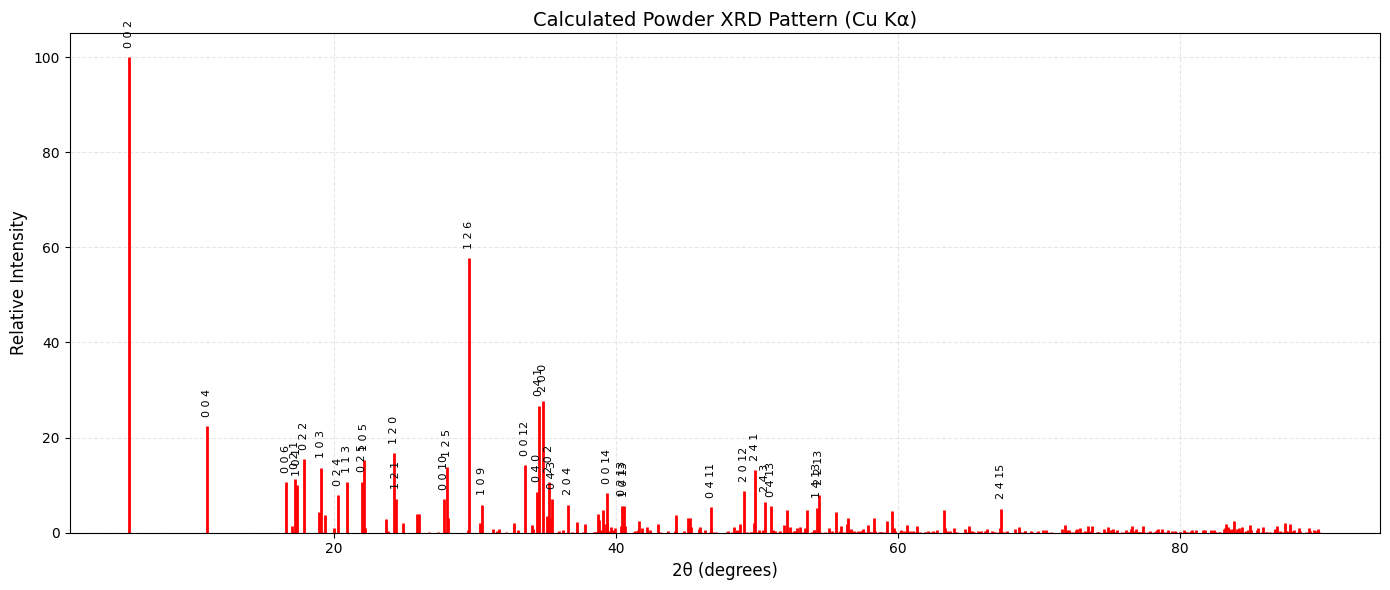

In [14]:
fig = plot_pattern_with_hkl(pattern, title="Calculated Powder XRD Pattern (Cu Kα)")
plt.show()

## 2. Experimental Data (BRML)

Now, we read and plot experimental data from a Bruker BRML file.

Loaded 5449 data points.


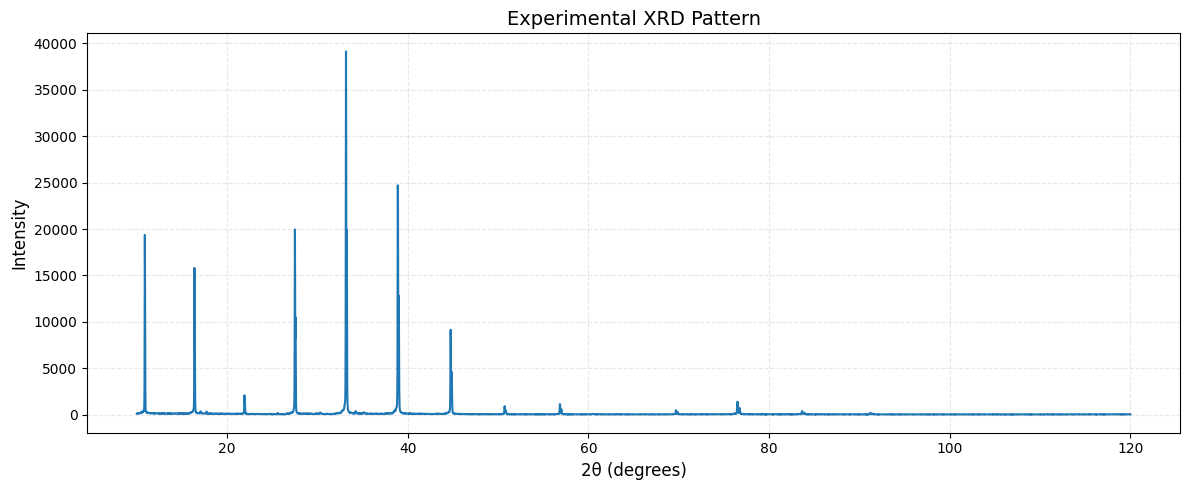

In [ ]:
# Read BRML file
exp_id = 3623
brml_file = f"20260422/{exp_id}.brml"
two_theta, intensity = read_brml(brml_file)

print(f"Loaded {len(two_theta)} data points.")

# Plot the data
plot_brml(two_theta, intensity, title="Experimental XRD Pattern")
plt.show()

## 3. Highlighting Specific Peaks

Sometimes we only want to see a specific series of peaks, such as the (00l) reflections.

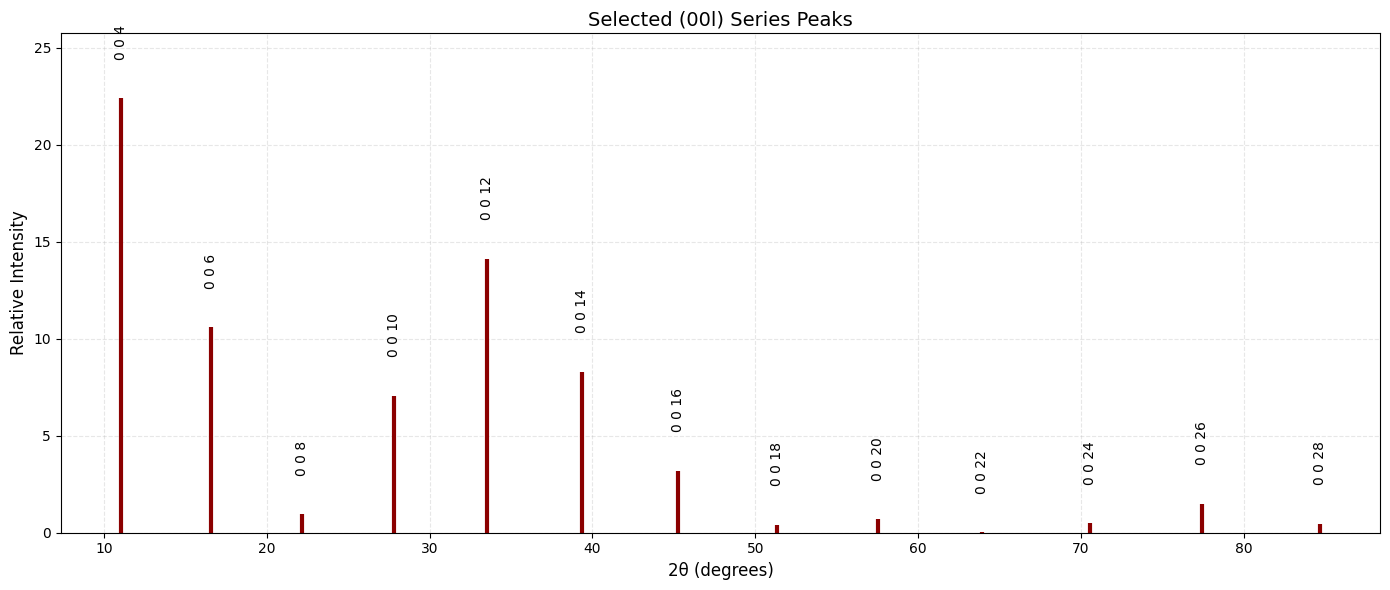

In [27]:
selected_hkl = [(0,0,x) for x in range(4,30,2)]

fig = plot_selected_hkl(
    pattern, 
    selected_hkl, 
    title="Selected (00l) Series Peaks",
    color='darkred'
)
plt.show()

## 4. Overlap: Theory vs Experiment

Finally, we can overlap our selected theoretical peaks with the experimental data to verify our results.

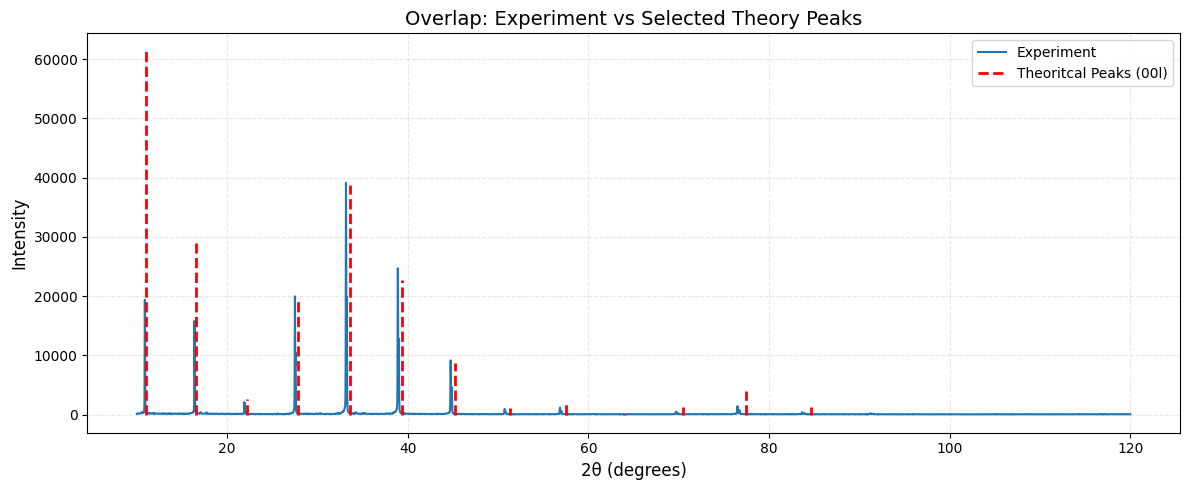

In [ ]:
# 1. Create the base experimental plot
fig = plot_brml(two_theta, intensity, title="Overlap: Experiment vs Selected Theory Peaks")
ax = fig.axes[0]

# 2. Scale theoretical peaks to match experiment's intensity scale
# The library's pattern.y is scaled to 100 by default.
scaling_factor = intensity.max() / 100 * 7

# 3. Overlay the selected (00l) peaks as vertical lines
hkl_set = set(selected_hkl)
for i, (tt, inten) in enumerate(zip(pattern.x, pattern.y)):
    if pattern.hkls[i] and pattern.hkls[i][0]['hkl'] in hkl_set:
        ax.vlines(tt, 0, inten * scaling_factor, 
                  color='red', linewidth=2, linestyle='--', 
                  label='Theory (00l)' if 'Theory' not in ax.get_legend_handles_labels()[1] else "")

ax.legend([f"Experiment {exp_id}", "Theoritcal Peaks (00l)"])
plt.show()